In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
print("Notebook is working")

Notebook is working


In [2]:
users = pd.read_csv("../data/raw/users.csv")
kyc = pd.read_csv("../data/raw/kyc_events.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")
feedback = pd.read_csv("../data/raw/user_feedback.csv")

print(users.shape)
print(kyc.shape)
print(transactions.shape)
print(feedback.shape)

users.head()

(2000, 6)
(7277, 5)
(950, 6)
(2000, 3)


,user_id,signup_date,device_type,acquisition_channel,region,age_group
0,1001,2025-02-21,Android,Referral,South,18-24
1,1002,2025-01-15,iOS,Organic,South,25-34
2,1003,2025-03-13,iOS,Paid Social,Northeast,35-44
3,1004,2025-03-02,iOS,Paid Social,South,25-34
4,1005,2025-01-21,Web,Search,Midwest,45-54


In [3]:
funnel_counts = kyc.groupby("event_name")["user_id"].nunique().reset_index()
funnel_counts.columns = ["stage", "users"]

deposit_users = transactions[transactions["transaction_type"] == "deposit"]["user_id"].nunique()
payment_users = transactions[transactions["transaction_type"] == "payment"]["user_id"].nunique()

extra_stages = pd.DataFrame({
    "stage": ["first_deposit", "first_transaction"],
    "users": [deposit_users, payment_users]
})

funnel_counts = pd.concat([funnel_counts, extra_stages], ignore_index=True)

stage_order = [
    "account_created",
    "phone_verified",
    "kyc_started",
    "kyc_approved",
    "bank_linked",
    "first_deposit",
    "first_transaction"
]

funnel_counts["stage"] = pd.Categorical(funnel_counts["stage"], categories=stage_order, ordered=True)
funnel_counts = funnel_counts.sort_values("stage")

funnel_counts

,stage,users
0,account_created,2000
4,phone_verified,1857
3,kyc_started,1520
2,kyc_approved,1098
1,bank_linked,802
5,first_deposit,551
6,first_transaction,399


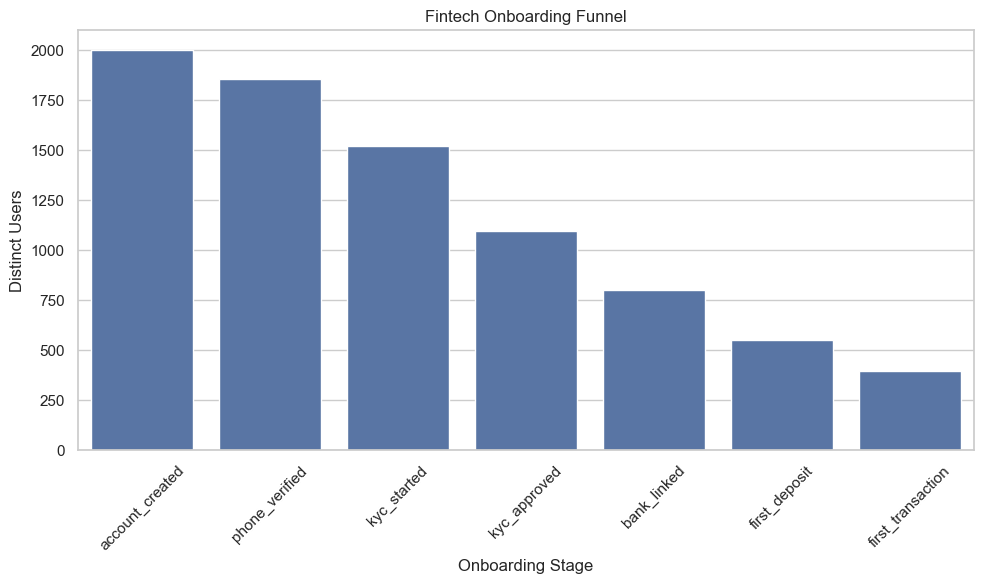

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(data=funnel_counts, x="stage", y="users")
plt.xticks(rotation=45)
plt.title("Fintech Onboarding Funnel")
plt.ylabel("Distinct Users")
plt.xlabel("Onboarding Stage")
plt.tight_layout()
plt.savefig("../outputs/charts/funnel_chart.png", dpi=300)
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set(style="whitegrid")

users = pd.read_csv("../data/raw/users.csv")
kyc = pd.read_csv("../data/raw/kyc_events.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")
feedback = pd.read_csv("../data/raw/user_feedback.csv")

print("users:", users.shape)
print("kyc:", kyc.shape)
print("transactions:", transactions.shape)
print("feedback:", feedback.shape)

feedback.head()

users: (2000, 6)
kyc: (7277, 5)
transactions: (950, 6)
feedback: (2000, 3)


,user_id,signup_feedback,sentiment_label
0,1001,App froze during document upload,negative
1,1002,The verification process is confusing,negative
2,1003,The instructions were unclear,negative
3,1004,I want an easier way to transfer money,neutral
4,1005,The app was very easy to use,positive


In [7]:
feedback["sentiment_label"].value_counts()

sentiment_label
neutral     997
positive    540
negative    463
Name: count, dtype: int64

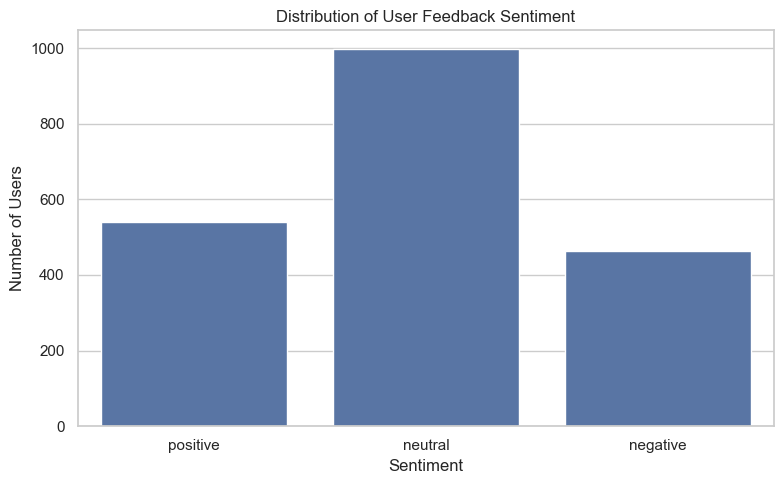

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=feedback, x="sentiment_label", order=["positive", "neutral", "negative"])
plt.title("Distribution of User Feedback Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

In [9]:
approved_users = set(kyc[kyc["event_name"] == "kyc_approved"]["user_id"])
started_users = set(kyc[kyc["event_name"] == "kyc_started"]["user_id"])
bank_linked_users = set(kyc[kyc["event_name"] == "bank_linked"]["user_id"])

feedback["kyc_started"] = feedback["user_id"].isin(started_users)
feedback["kyc_approved"] = feedback["user_id"].isin(approved_users)
feedback["bank_linked"] = feedback["user_id"].isin(bank_linked_users)

feedback.head()

,user_id,signup_feedback,sentiment_label,kyc_started,kyc_approved,bank_linked
0,1001,App froze during document upload,negative,True,False,False
1,1002,The verification process is confusing,negative,True,False,False
2,1003,The instructions were unclear,negative,True,False,False
3,1004,I want an easier way to transfer money,neutral,False,False,False
4,1005,The app was very easy to use,positive,True,True,True


In [10]:
approval_by_sentiment = feedback.groupby("sentiment_label")["kyc_approved"].mean().reset_index()
approval_by_sentiment["kyc_approved"] = approval_by_sentiment["kyc_approved"] * 100
approval_by_sentiment

,sentiment_label,kyc_approved
0,negative,0.000000
1,neutral,55.967904
2,positive,100.000000


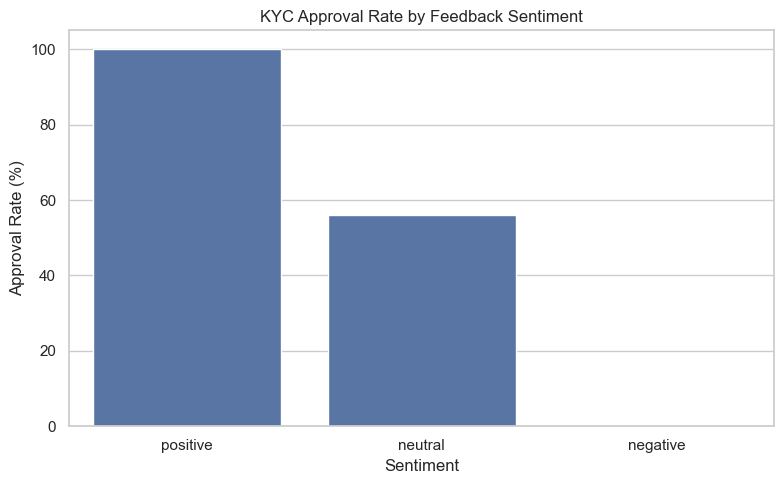

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(data=approval_by_sentiment, x="sentiment_label", y="kyc_approved", order=["positive", "neutral", "negative"])
plt.title("KYC Approval Rate by Feedback Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Approval Rate (%)")
plt.tight_layout()
plt.show()

In [12]:
negative_feedback = feedback[feedback["sentiment_label"] == "negative"].copy()
negative_feedback[["user_id", "signup_feedback"]].head(10)

,user_id,signup_feedback
0,1001,App froze during document upload
1,1002,The verification process is confusing
2,1003,The instructions were unclear
9,1010,The instructions were unclear
10,1011,App froze during document upload
12,1013,The verification process is confusing
14,1015,I had trouble linking my bank
20,1021,I had trouble linking my bank
26,1027,The instructions were unclear
54,1055,I had trouble linking my bank


In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

negative_feedback["cleaned_text"] = negative_feedback["signup_feedback"].apply(clean_text)
negative_feedback["tokens"] = negative_feedback["cleaned_text"].str.split()

negative_feedback.head()

,user_id,signup_feedback,sentiment_label,kyc_started,kyc_approved,bank_linked,cleaned_text,tokens
0,1001,App froze during document upload,negative,True,False,False,app froze during document upload,"[app, froze, during, document, upload]"
1,1002,The verification process is confusing,negative,True,False,False,the verification process is confusing,"[the, verification, process, is, confusing]"
2,1003,The instructions were unclear,negative,True,False,False,the instructions were unclear,"[the, instructions, were, unclear]"
9,1010,The instructions were unclear,negative,False,False,False,the instructions were unclear,"[the, instructions, were, unclear]"
10,1011,App froze during document upload,negative,False,False,False,app froze during document upload,"[app, froze, during, document, upload]"


In [14]:
all_words = [word for tokens in negative_feedback["tokens"] for word in tokens]

stopwords = {
    "the", "is", "to", "my", "i", "it", "was", "during", "had", "of", "a", "and", "on"
}

filtered_words = [word for word in all_words if word not in stopwords]

word_counts = Counter(filtered_words)
word_counts.most_common(15)

[('app', 106),
 ('froze', 106),
 ('document', 106),
 ('upload', 106),
 ('trouble', 96),
 ('linking', 96),
 ('bank', 96),
 ('took', 92),
 ('too', 92),
 ('long', 92),
 ('verify', 92),
 ('account', 92),
 ('instructions', 90),
 ('were', 90),
 ('unclear', 90)]

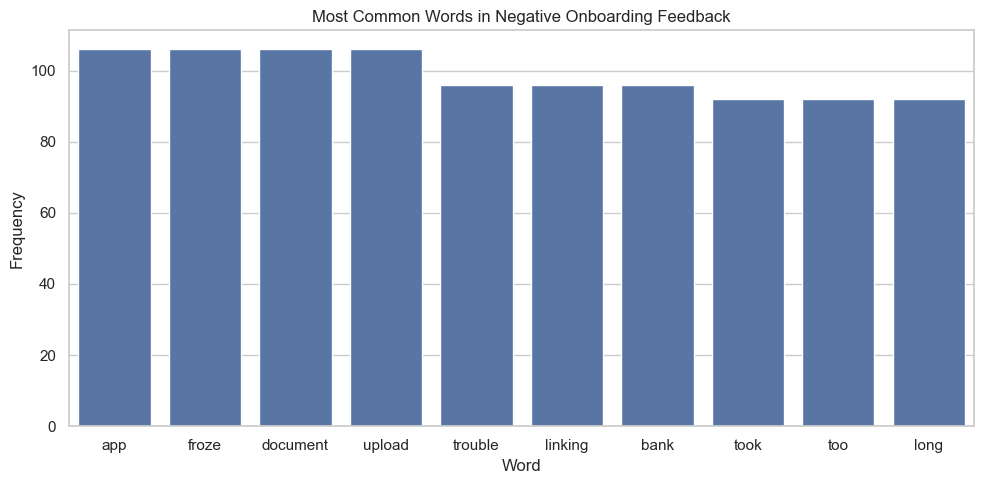

In [15]:
top_words_df = pd.DataFrame(word_counts.most_common(10), columns=["word", "count"])

plt.figure(figsize=(10, 5))
sns.barplot(data=top_words_df, x="word", y="count")
plt.title("Most Common Words in Negative Onboarding Feedback")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [16]:
not_approved_negative = negative_feedback[negative_feedback["kyc_approved"] == False].copy()

all_words_not_approved = [word for tokens in not_approved_negative["tokens"] for word in tokens]
filtered_words_not_approved = [word for word in all_words_not_approved if word not in stopwords]

word_counts_not_approved = Counter(filtered_words_not_approved)
word_counts_not_approved.most_common(10)

[('app', 106),
 ('froze', 106),
 ('document', 106),
 ('upload', 106),
 ('trouble', 96),
 ('linking', 96),
 ('bank', 96),
 ('took', 92),
 ('too', 92),
 ('long', 92)]

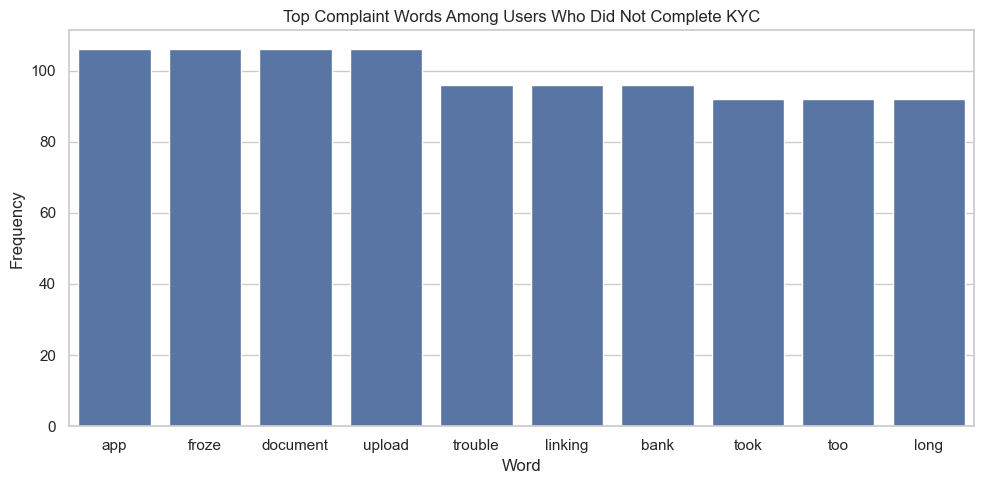

In [17]:
top_fail_words_df = pd.DataFrame(word_counts_not_approved.most_common(10), columns=["word", "count"])

plt.figure(figsize=(10, 5))
sns.barplot(data=top_fail_words_df, x="word", y="count")
plt.title("Top Complaint Words Among Users Who Did Not Complete KYC")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## NLP Insight Summary

Negative onboarding feedback was associated with lower KYC approval rates.  
The most common complaint terms among non-approved users included:
- verification
- unclear
- upload
- bank

This suggests that onboarding friction may be concentrated in identity verification and account-linking steps.

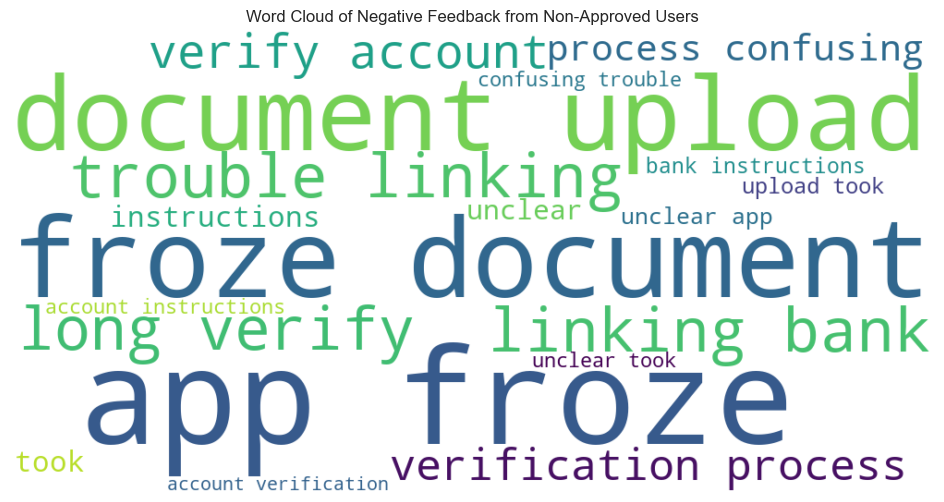

In [18]:
from wordcloud import WordCloud

text_blob = " ".join(filtered_words_not_approved)

wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(text_blob)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Negative Feedback from Non-Approved Users")
plt.show()